In [7]:
!pip install nltk scikit-learn

In [8]:
import pandas as pd
import numpy as np
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [9]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [14]:
df = pd.read_csv('/content/IMDB_Dataset.csv', engine='python', on_bad_lines='skip')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [15]:
print(df.shape)

df.info()

(26907, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26907 entries, 0 to 26906
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     26907 non-null  object
 1   sentiment  26907 non-null  object
dtypes: object(2)
memory usage: 420.6+ KB


In [16]:
print(df['sentiment'].value_counts())

sentiment
positive    13485
negative    13422
Name: count, dtype: int64


In [17]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df['clean_review'] = df['review'].apply(preprocess)

df[['review','clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


In [18]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    df['clean_review']
)

y = df['sentiment']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

MultinomialNB()

In [21]:
y_pred = model.predict(
    X_test
)

In [22]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.8600891861761427
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      2719
    positive       0.85      0.87      0.86      2663

    accuracy                           0.86      5382
   macro avg       0.86      0.86      0.86      5382
weighted avg       0.86      0.86      0.86      5382



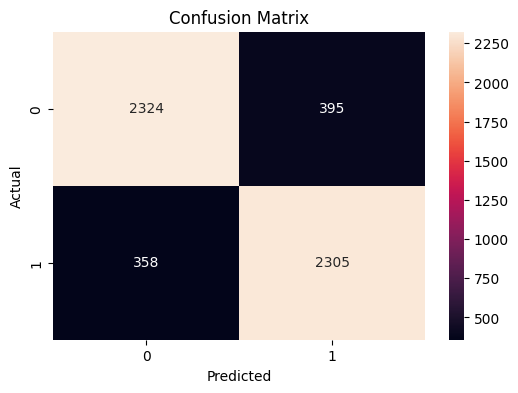

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix"
)

plt.show()

In [24]:
review = [
    "This movie was fantastic and amazing"
]

review_clean = [
    preprocess(review[0])
]

review_tfidf = tfidf.transform(
    review_clean
)

prediction = model.predict(
    review_tfidf
)

print(
    "Sentiment:",
    prediction[0]
)

Sentiment: positive
